In [1]:
#1.Import Libraries

In [2]:
import pandas as pd
import numpy as np
import time
import pickle
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, chi2, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [3]:
#2.RFE Feature Selection Function

In [4]:
def rfeFeature(indep_X, dep_Y, n):
    rfelist = []
    # scale only for RFE ranking (faster convergence for linear models / SVR)
    X_scaled = StandardScaler().fit_transform(indep_X)
    log_model = LogisticRegression(solver='lbfgs', max_iter=1000)
    RF = RandomForestClassifier(n_estimators=10, criterion='entropy', random_state=0)
    DT = DecisionTreeClassifier(criterion='gini', max_features='sqrt', splitter='best', random_state=0)
    svc_model = SVC(kernel='linear', random_state=0)
    rfemodellist = [log_model, svc_model, RF, DT]
    for i in rfemodellist:
        print(i)
        log_rfe = RFE(estimator=i, n_features_to_select=n)
        log_fit = log_rfe.fit(X_scaled, dep_Y)
        print('  Selected features:', list(indep_X.columns[log_fit.support_]))
        log_rfe_feature = indep_X.loc[:, log_fit.support_].values  # original (unscaled) selected columns
        rfelist.append(log_rfe_feature)
    return rfelist

In [5]:
#3.Split & Scale Function

In [6]:
def split_scalar(indep_X, dep_Y):
    X_train, X_test, y_train, y_test = train_test_split(indep_X, dep_Y, test_size=0.25, random_state=0)
    sc = StandardScaler()
    X_train = sc.fit_transform(X_train)
    X_test = sc.transform(X_test)
    return X_train, X_test, y_train, y_test

In [7]:
#4.Prediction & Evaluation Function

In [8]:
def cm_prediction(classifier, X_test):
    y_pred = classifier.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    Accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    return classifier, Accuracy, report, X_test, y_test, cm

In [9]:
#5.Classification Model Functions

In [10]:
def logistic(X_train, y_train, X_test):
    classifier = LogisticRegression(random_state=0)
    classifier.fit(X_train, y_train)
    return cm_prediction(classifier, X_test)

def svm_linear(X_train, y_train, X_test):
    classifier = SVC(kernel='linear', random_state=0)
    classifier.fit(X_train, y_train)
    return cm_prediction(classifier, X_test)

def svm_NL(X_train, y_train, X_test):
    classifier = SVC(kernel='rbf', random_state=0)
    classifier.fit(X_train, y_train)
    return cm_prediction(classifier, X_test)

def Navie(X_train, y_train, X_test):
    classifier = GaussianNB()
    classifier.fit(X_train, y_train)
    return cm_prediction(classifier, X_test)

def knn(X_train, y_train, X_test):
    classifier = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
    classifier.fit(X_train, y_train)
    return cm_prediction(classifier, X_test)

def Decision(X_train, y_train, X_test):
    classifier = DecisionTreeClassifier(criterion='entropy', random_state=0)
    classifier.fit(X_train, y_train)
    return cm_prediction(classifier, X_test)

def random(X_train, y_train, X_test):
    classifier = RandomForestClassifier(n_estimators=10, criterion='entropy', random_state=0)
    classifier.fit(X_train, y_train)
    return cm_prediction(classifier, X_test)

In [11]:
#6.Result Table Function

In [12]:
def rfe_classification(acclog, accsvml, accsvmnl, accknn, accnav, accdes, accrf):
    rfedataframe = pd.DataFrame(index=['Logistic', 'SVC', 'Random', 'DecisionTree'],
                                columns=['Logistic', 'SVMl', 'SVMnl', 'KNN', 'Navie', 'Decision', 'Random'])
    for number, idex in enumerate(rfedataframe.index):
        rfedataframe.loc[idex, 'Logistic'] = acclog[number]
        rfedataframe.loc[idex, 'SVMl'] = accsvml[number]
        rfedataframe.loc[idex, 'SVMnl'] = accsvmnl[number]
        rfedataframe.loc[idex, 'KNN'] = accknn[number]
        rfedataframe.loc[idex, 'Navie'] = accnav[number]
        rfedataframe.loc[idex, 'Decision'] = accdes[number]
        rfedataframe.loc[idex, 'Random'] = accrf[number]
    return rfedataframe.astype(float)

In [13]:
#7.Load Data

In [14]:
dataset1 = pd.read_csv("prep.csv", index_col=None)
df2 = dataset1
df2 = pd.get_dummies(df2, drop_first=True)
df2.head()

,age,bp,al,su,bgr,bu,sc,sod,pot,hrmo,...,pc_normal,pcc_present,ba_present,htn_yes,dm_yes,cad_yes,appet_yes,pe_yes,ane_yes,classification_yes
0,2.0,76.459948,3.0,0.0,148.112676,57.482105,3.077356,137.528754,4.627244,12.518156,...,False,False,False,False,False,False,True,True,False,True
1,3.0,76.459948,2.0,0.0,148.112676,22.000000,0.700000,137.528754,4.627244,10.700000,...,True,False,False,False,False,False,True,False,False,True
2,4.0,76.459948,1.0,0.0,99.000000,23.000000,0.600000,138.000000,4.400000,12.000000,...,True,False,False,False,False,False,True,False,False,True
3,5.0,76.459948,1.0,0.0,148.112676,16.000000,0.700000,138.000000,3.200000,8.100000,...,True,False,False,False,False,False,True,False,True,True
4,5.0,50.000000,0.0,0.0,148.112676,25.000000,0.600000,137.528754,4.627244,11.800000,...,True,False,False,False,False,False,True,False,False,True


In [15]:
indep_X = df2.drop('classification_yes', axis=1)
dep_Y = df2['classification_yes']
print(indep_X.shape, dep_Y.shape)

(399, 27) (399,)


In [16]:
#8.Run RFE (select top 3 features)

In [17]:
rfelist = rfeFeature(indep_X, dep_Y, 3)

LogisticRegression(max_iter=1000)
  Selected features: ['al', 'hrmo', 'dm_yes']
SVC(kernel='linear', random_state=0)
  Selected features: ['sc', 'hrmo', 'sg_d']
RandomForestClassifier(criterion='entropy', n_estimators=10, random_state=0)
  Selected features: ['sc', 'hrmo', 'pcv']
DecisionTreeClassifier(max_features='sqrt', random_state=0)
  Selected features: ['sc', 'pcv', 'sg_d']


In [18]:
#9.Train All Classifiers on Each RFE Feature Set

In [19]:
acclog = []
accsvml = []
accsvmnl = []
accknn = []
accnav = []
accdes = []
accrf = []

for i in rfelist:
    X_train, X_test, y_train, y_test = split_scalar(i, dep_Y)

    classifier, Accuracy, report, X_test, y_test, cm = logistic(X_train, y_train, X_test)
    acclog.append(Accuracy)

    classifier, Accuracy, report, X_test, y_test, cm = svm_linear(X_train, y_train, X_test)
    accsvml.append(Accuracy)

    classifier, Accuracy, report, X_test, y_test, cm = svm_NL(X_train, y_train, X_test)
    accsvmnl.append(Accuracy)

    classifier, Accuracy, report, X_test, y_test, cm = knn(X_train, y_train, X_test)
    accknn.append(Accuracy)

    classifier, Accuracy, report, X_test, y_test, cm = Navie(X_train, y_train, X_test)
    accnav.append(Accuracy)

    classifier, Accuracy, report, X_test, y_test, cm = Decision(X_train, y_train, X_test)
    accdes.append(Accuracy)

    classifier, Accuracy, report, X_test, y_test, cm = random(X_train, y_train, X_test)
    accrf.append(Accuracy)

In [20]:
#10.Result (rows = RFE selector, columns = classifier, values = Accuracy)

In [21]:
result = rfe_classification(acclog, accsvml, accsvmnl, accknn, accnav, accdes, accrf)
result

,Logistic,SVMl,SVMnl,KNN,Navie,Decision,Random
Logistic,0.98,0.98,0.99,0.99,0.91,0.99,0.99
SVC,0.97,0.98,0.98,0.98,0.75,0.93,0.97
Random,0.94,0.94,0.94,0.94,0.90,0.91,0.92
DecisionTree,0.93,0.93,0.94,0.95,0.74,0.95,0.97


In [22]:
best = result.stack().idxmax()
print('Best combination -> RFE selector:', best[0], '| Classifier:', best[1], '| Accuracy:', round(result.stack().max(), 4))

Best combination -> RFE selector: Logistic | Classifier: SVMnl | Accuracy: 0.99


In [23]:
#11.Compare Number of Features (n = 3, 5, 7, 10)

In [25]:

n_list = [3, 5, 7, 10]
all_results = {}

for n in n_list:
    print('\n================ n =', n, '================')
    rfelist = rfeFeature(indep_X, dep_Y, n)

    acclog, accsvml, accsvmnl, accknn, accnav, accdes, accrf = [], [], [], [], [], [], []
    for i in rfelist:
        X_train, X_test, y_train, y_test = split_scalar(i, dep_Y)
        acclog.append(logistic(X_train, y_train, X_test)[1])
        accsvml.append(svm_linear(X_train, y_train, X_test)[1])
        accsvmnl.append(svm_NL(X_train, y_train, X_test)[1])
        accknn.append(knn(X_train, y_train, X_test)[1])
        accnav.append(Navie(X_train, y_train, X_test)[1])
        accdes.append(Decision(X_train, y_train, X_test)[1])
        accrf.append(random(X_train, y_train, X_test)[1])

    all_results[n] = rfe_classification(acclog, accsvml, accsvmnl, accknn, accnav, accdes, accrf)
    display(all_results[n])

summary = []
for n, res in all_results.items():
    best = res.stack().idxmax()
    summary.append({'n_features': n, 'RFE_selector': best[0], 'Classifier': best[1],
                    'Best_Accuracy': round(res.stack().max(), 4),
                    'Mean_Accuracy (all combos)': round(res.stack().mean(), 4)})
summary_df = pd.DataFrame(summary).set_index('n_features')
summary_df




================ n = 3 ================
LogisticRegression(max_iter=1000)
  Selected features: ['al', 'hrmo', 'dm_yes']
SVC(kernel='linear', random_state=0)
  Selected features: ['sc', 'hrmo', 'sg_d']
RandomForestClassifier(criterion='entropy', n_estimators=10, random_state=0)
  Selected features: ['sc', 'hrmo', 'pcv']
DecisionTreeClassifier(max_features='sqrt', random_state=0)
  Selected features: ['sc', 'pcv', 'sg_d']


,Logistic,SVMl,SVMnl,KNN,Navie,Decision,Random
Logistic,0.98,0.98,0.99,0.99,0.91,0.99,0.99
SVC,0.97,0.98,0.98,0.98,0.75,0.93,0.97
Random,0.94,0.94,0.94,0.94,0.90,0.91,0.92
DecisionTree,0.93,0.93,0.94,0.95,0.74,0.95,0.97



================ n = 5 ================
LogisticRegression(max_iter=1000)
  Selected features: ['al', 'hrmo', 'pcv', 'sg_c', 'dm_yes']
SVC(kernel='linear', random_state=0)
  Selected features: ['al', 'sc', 'hrmo', 'pcv', 'sg_d']
RandomForestClassifier(criterion='entropy', n_estimators=10, random_state=0)
  Selected features: ['al', 'bgr', 'sc', 'hrmo', 'pcv']
DecisionTreeClassifier(max_features='sqrt', random_state=0)
  Selected features: ['age', 'sc', 'pcv', 'sg_c', 'sg_d']


,Logistic,SVMl,SVMnl,KNN,Navie,Decision,Random
Logistic,0.98,0.97,0.99,0.99,0.93,0.99,0.99
SVC,0.98,0.97,0.99,1.00,0.91,0.98,0.99
Random,0.97,0.97,0.98,0.97,0.91,0.96,0.98
DecisionTree,0.95,0.96,0.97,0.97,0.84,0.94,0.96



================ n = 7 ================
LogisticRegression(max_iter=1000)
  Selected features: ['al', 'sc', 'hrmo', 'pcv', 'sg_c', 'sg_d', 'dm_yes']
SVC(kernel='linear', random_state=0)
  Selected features: ['al', 'sc', 'hrmo', 'pcv', 'sg_c', 'sg_d', 'dm_yes']
RandomForestClassifier(criterion='entropy', n_estimators=10, random_state=0)
  Selected features: ['al', 'bgr', 'sc', 'sod', 'hrmo', 'pcv', 'rc']
DecisionTreeClassifier(max_features='sqrt', random_state=0)
  Selected features: ['age', 'sc', 'pcv', 'sg_c', 'sg_d', 'appet_yes', 'pe_yes']


,Logistic,SVMl,SVMnl,KNN,Navie,Decision,Random
Logistic,0.99,0.99,0.99,0.98,0.97,0.95,1.00
SVC,0.99,0.99,0.99,0.98,0.97,0.95,1.00
Random,0.98,0.98,0.98,0.98,0.91,0.96,0.96
DecisionTree,0.97,0.97,0.99,0.99,0.93,0.95,0.98



================ n = 10 ================
LogisticRegression(max_iter=1000)
  Selected features: ['al', 'bgr', 'sc', 'hrmo', 'pcv', 'sg_c', 'sg_d', 'htn_yes', 'dm_yes', 'appet_yes']
SVC(kernel='linear', random_state=0)
  Selected features: ['al', 'bgr', 'sc', 'hrmo', 'pcv', 'rc', 'sg_c', 'sg_d', 'dm_yes', 'appet_yes']
RandomForestClassifier(criterion='entropy', n_estimators=10, random_state=0)
  Selected features: ['al', 'bgr', 'bu', 'sc', 'sod', 'hrmo', 'pcv', 'rc', 'sg_d', 'htn_yes']
DecisionTreeClassifier(max_features='sqrt', random_state=0)
  Selected features: ['age', 'sc', 'pcv', 'sg_c', 'sg_d', 'htn_yes', 'cad_yes', 'appet_yes', 'pe_yes', 'ane_yes']


,Logistic,SVMl,SVMnl,KNN,Navie,Decision,Random
Logistic,1.00,0.99,1.00,0.99,0.98,0.98,1.00
SVC,1.00,0.99,1.00,1.00,0.99,0.98,1.00
Random,0.99,0.98,1.00,1.00,0.96,0.97,1.00
DecisionTree,0.97,0.97,0.98,1.00,0.96,0.98,0.98


,RFE_selector,Classifier,Best_Accuracy,Mean_Accuracy (all combos)
n_features,,,,
3,Logistic,SVMnl,0.99,0.9389
5,SVC,KNN,1.00,0.9639
7,Logistic,Random,1.00,0.9739
10,Logistic,Logistic,1.00,0.9871


In [26]:
#12-Fold Cross-Validation


In [27]:

from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

selectors = {
    'Logistic': LogisticRegression(solver='lbfgs', max_iter=1000),
    'SVC': SVC(kernel='linear', random_state=0),
    'Random': RandomForestClassifier(n_estimators=10, criterion='entropy', random_state=0),
    'DecisionTree': DecisionTreeClassifier(criterion='gini', max_features='sqrt', splitter='best', random_state=0),
}
classifiers = {
    'Logistic': LogisticRegression(random_state=0),
    'SVMl': SVC(kernel='linear', random_state=0),
    'SVMnl': SVC(kernel='rbf', random_state=0),
    'KNN': KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2),
    'Navie': GaussianNB(),
    'Decision': DecisionTreeClassifier(criterion='entropy', random_state=0),
    'Random': RandomForestClassifier(n_estimators=10, criterion='entropy', random_state=0),
}

cv_results = {}
cv_rows = []
for n in n_list:
    table = pd.DataFrame(index=list(selectors), columns=list(classifiers), dtype=float)
    for s_name, s_model in selectors.items():
        for c_name, c_model in classifiers.items():
            pipe = Pipeline([('scale', StandardScaler()),
                             ('rfe', RFE(estimator=s_model, n_features_to_select=n)),
                             ('model', c_model)])
            scores = cross_val_score(pipe, indep_X, dep_Y, cv=cv, scoring='accuracy')
            table.loc[s_name, c_name] = scores.mean()
            cv_rows.append({'n_features': n, 'RFE_selector': s_name, 'Classifier': c_name,
                            'CV_Mean': scores.mean(), 'CV_Std': scores.std()})
    cv_results[n] = table
    print('\n===== n =', n, '| 5-fold CV mean accuracy =====')
    display(table.round(4))

cv_df = pd.DataFrame(cv_rows)

cv_summary = (cv_df.sort_values('CV_Mean', ascending=False)
                   .groupby('n_features').head(1)
                   .set_index('n_features').sort_index().round(4))
cv_summary


===== n = 3 | 5-fold CV mean accuracy =====


,Logistic,SVMl,SVMnl,KNN,Navie,Decision,Random
Logistic,0.9650,0.9625,0.9625,0.9650,0.8094,0.9625,0.9650
SVC,0.9574,0.9474,0.9473,0.9523,0.7797,0.9373,0.9448
Random,0.9399,0.9424,0.9398,0.9273,0.9072,0.9198,0.9348
DecisionTree,0.9575,0.9524,0.9575,0.9474,0.8848,0.9498,0.9599



===== n = 5 | 5-fold CV mean accuracy =====


,Logistic,SVMl,SVMnl,KNN,Navie,Decision,Random
Logistic,0.9699,0.9800,0.9800,0.9750,0.8948,0.9750,0.9775
SVC,0.9699,0.9699,0.9674,0.9599,0.8497,0.9749,0.9549
Random,0.9624,0.9649,0.9674,0.9574,0.8999,0.9574,0.9574
DecisionTree,0.9524,0.9650,0.9650,0.9575,0.8146,0.9573,0.9574



===== n = 7 | 5-fold CV mean accuracy =====


,Logistic,SVMl,SVMnl,KNN,Navie,Decision,Random
Logistic,0.9825,0.9825,0.9850,0.9825,0.9724,0.9825,0.9825
SVC,0.9775,0.9825,0.9800,0.9850,0.9324,0.9750,0.9800
Random,0.9750,0.9725,0.9750,0.9699,0.9173,0.9548,0.9649
DecisionTree,0.9549,0.9624,0.9625,0.9499,0.8622,0.9548,0.9674



===== n = 10 | 5-fold CV mean accuracy =====


,Logistic,SVMl,SVMnl,KNN,Navie,Decision,Random
Logistic,0.9750,0.9800,0.9750,0.9725,0.9775,0.9800,0.9849
SVC,0.9724,0.9725,0.9799,0.9774,0.9649,0.9724,0.9775
Random,0.9775,0.9724,0.9775,0.9649,0.9323,0.9548,0.9724
DecisionTree,0.9624,0.9675,0.9649,0.9650,0.9149,0.9548,0.9749


,RFE_selector,Classifier,CV_Mean,CV_Std
n_features,,,,
3,Logistic,Logistic,0.9650,0.0183
5,Logistic,SVMnl,0.9800,0.0100
7,SVC,KNN,0.9850,0.0094
10,Logistic,Random,0.9849,0.0124


In [30]:
#FINAL CROSS VALIDATION BEST MODEL

In [28]:
best_row = cv_df.sort_values(['CV_Mean', 'CV_Std'], ascending=[False, True]).iloc[0]
print('FINAL (cross-validated) best:')
print('  n_features   :', best_row['n_features'])
print('  RFE selector :', best_row['RFE_selector'])
print('  Classifier   :', best_row['Classifier'])
print('  CV Accuracy  : %.4f ± %.4f' % (best_row['CV_Mean'], best_row['CV_Std']))

FINAL (cross-validated) best:
  n_features   : 7
  RFE selector : SVC
  Classifier   : KNN
  CV Accuracy  : 0.9850 ± 0.0094


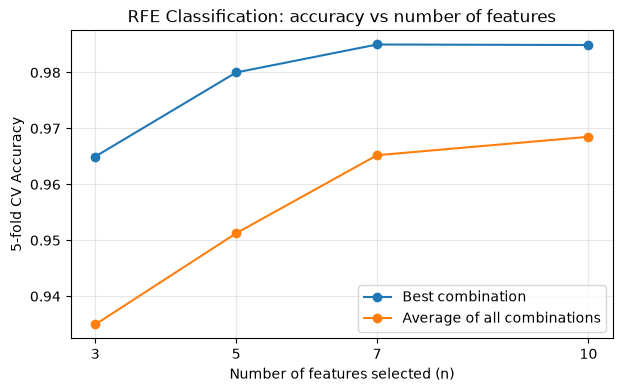

In [29]:
plt.figure(figsize=(7, 4))
best_per_n = cv_df.groupby('n_features')['CV_Mean'].max()
mean_per_n = cv_df.groupby('n_features')['CV_Mean'].mean()
plt.plot(best_per_n.index, best_per_n.values, marker='o', label='Best combination')
plt.plot(mean_per_n.index, mean_per_n.values, marker='o', label='Average of all combinations')
plt.xticks(n_list)
plt.xlabel('Number of features selected (n)')
plt.ylabel('5-fold CV Accuracy')
plt.title('RFE Classification: accuracy vs number of features')
plt.legend()
plt.grid(alpha=0.3)
plt.show()